<a href="https://colab.research.google.com/github/Gungun27/Gungun/blob/main/classification_wine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving WineQT.csv to WineQT (1).csv


In [ ]:
df = pd.read_csv("WineQT.csv")

In [ ]:
print("\nDataset Shape:")
print(df.shape)


Dataset Shape:
(1143, 13)


In [ ]:
print("\nFirst 5 Rows:")
print(df.head())



First 5 Rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5

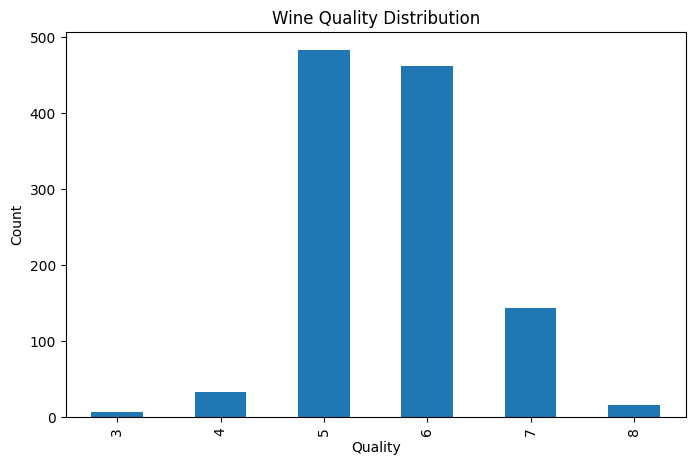

In [ ]:
plt.figure(figsize=(8,5))
df['quality'].value_counts().sort_index().plot(kind='bar')
plt.title("Wine Quality Distribution")
plt.xlabel("Quality")
plt.ylabel("Count")
plt.show()

In [ ]:
X = df.drop("quality", axis=1)
y = df["quality"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [ ]:
scaler = StandardScaler()

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("\nLOGISTIC REGRESSION")
print("Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print(classification_report(
    y_test,
    y_pred_lr
))



LOGISTIC REGRESSION
Accuracy: 0.6375545851528385
              precision    recall  f1-score   support

           4       0.00      0.00      0.00         6
           5       0.68      0.73      0.70        96
           6       0.63      0.64      0.63        99
           7       0.52      0.50      0.51        26
           8       0.00      0.00      0.00         2

    accuracy                           0.64       229
   macro avg       0.37      0.37      0.37       229
weighted avg       0.62      0.64      0.63       229



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


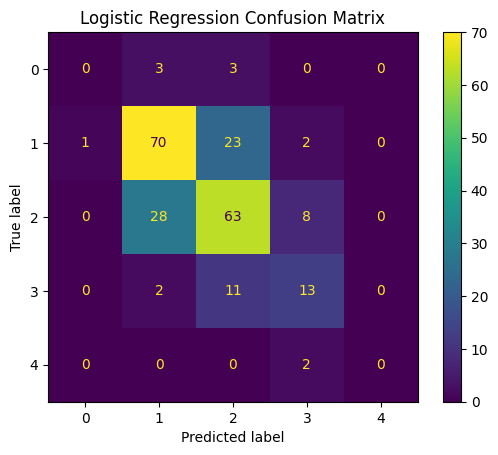

In [ ]:
cm = confusion_matrix(y_test, y_pred_lr)

ConfusionMatrixDisplay(cm).plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [ ]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("\nDECISION TREE")

print("Accuracy:",
      accuracy_score(y_test, y_pred_dt))

print(classification_report(
    y_test,
    y_pred_dt
))


DECISION TREE
Accuracy: 0.5633187772925764
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         0
           4       0.33      0.33      0.33         6
           5       0.65      0.66      0.65        96
           6       0.56      0.45      0.50        99
           7       0.45      0.69      0.55        26
           8       0.33      0.50      0.40         2

    accuracy                           0.56       229
   macro avg       0.39      0.44      0.41       229
weighted avg       0.58      0.56      0.56       229



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\nRANDOM FOREST")

print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print(classification_report(
    y_test,
    y_pred_rf
))



RANDOM FOREST
Accuracy: 0.6812227074235808
              precision    recall  f1-score   support

           4       0.00      0.00      0.00         6
           5       0.73      0.75      0.74        96
           6       0.63      0.70      0.66        99
           7       0.75      0.58      0.65        26
           8       0.00      0.00      0.00         2

    accuracy                           0.68       229
   macro avg       0.42      0.40      0.41       229
weighted avg       0.66      0.68      0.67       229



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


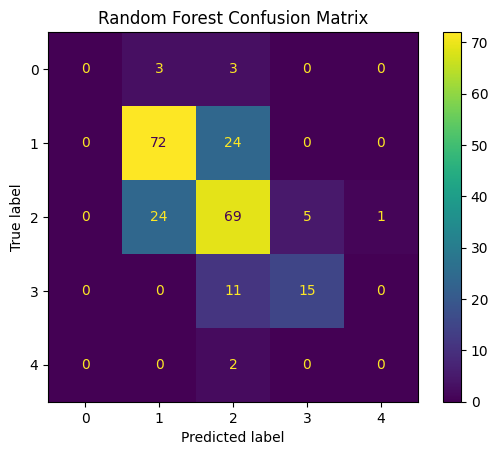

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)

ConfusionMatrixDisplay(cm).plot()
plt.title("Random Forest Confusion Matrix")
plt.show()


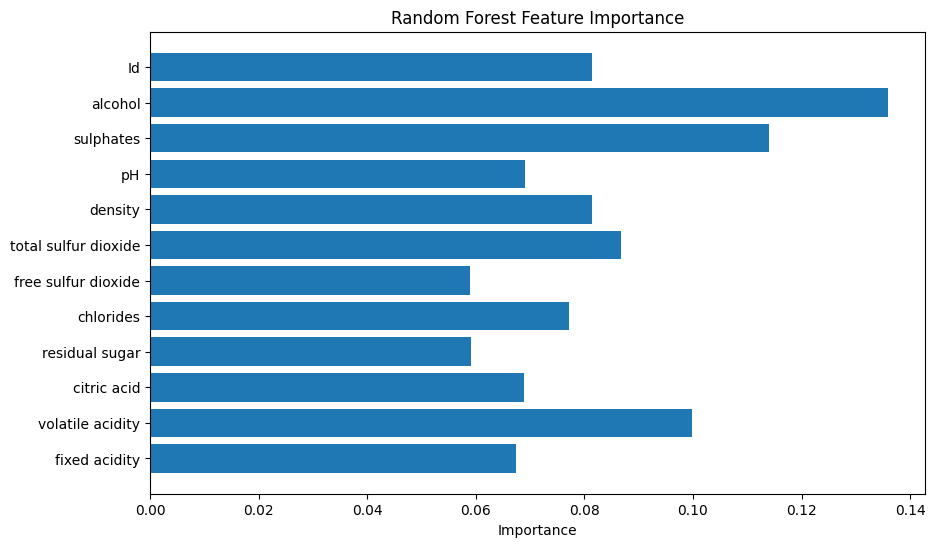

In [ ]:
importance = rf.feature_importances_

plt.figure(figsize=(10,6))
plt.barh(X.columns, importance)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

In [ ]:

knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("\nKNN")

print("Accuracy:",
      accuracy_score(y_test, y_pred_knn))

print(classification_report(
    y_test,
    y_pred_knn
))




KNN
Accuracy: 0.5589519650655022
              precision    recall  f1-score   support

           4       0.00      0.00      0.00         6
           5       0.63      0.67      0.65        96
           6       0.55      0.59      0.57        99
           7       0.32      0.23      0.27        26
           8       0.00      0.00      0.00         2

    accuracy                           0.56       229
   macro avg       0.30      0.30      0.30       229
weighted avg       0.54      0.56      0.55       229



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


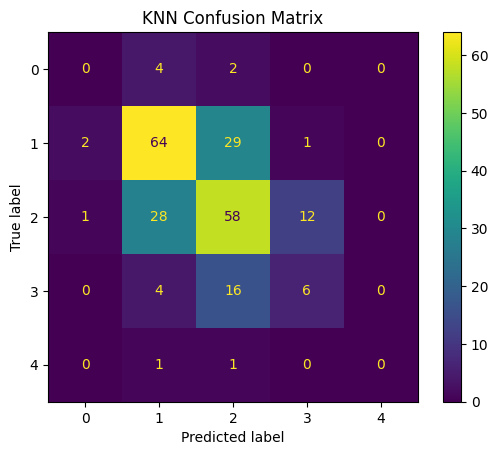

In [ ]:
cm = confusion_matrix(y_test, y_pred_knn)

ConfusionMatrixDisplay(cm).plot()
plt.title("KNN Confusion Matrix")
plt.show()


In [ ]:
model_accuracies = {
    "Logistic Regression":
        accuracy_score(y_test, y_pred_lr),

    "Decision Tree":
        accuracy_score(y_test, y_pred_dt),

    "Random Forest":
        accuracy_score(y_test, y_pred_rf),

    "KNN":
        accuracy_score(y_test, y_pred_knn)
}

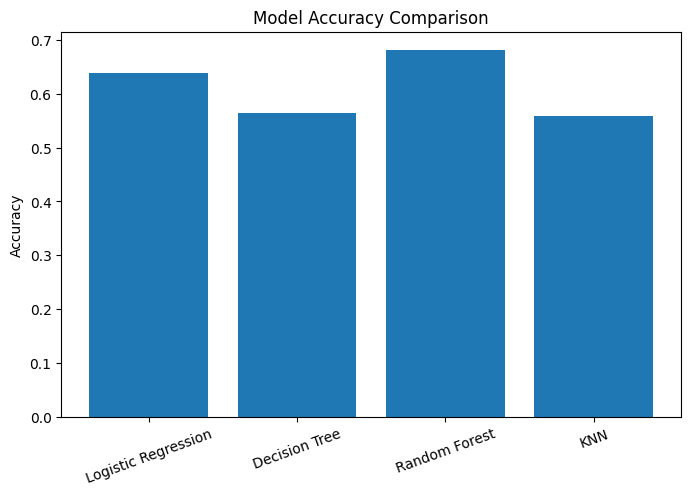

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    model_accuracies.keys(),
    model_accuracies.values()
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)

plt.show()


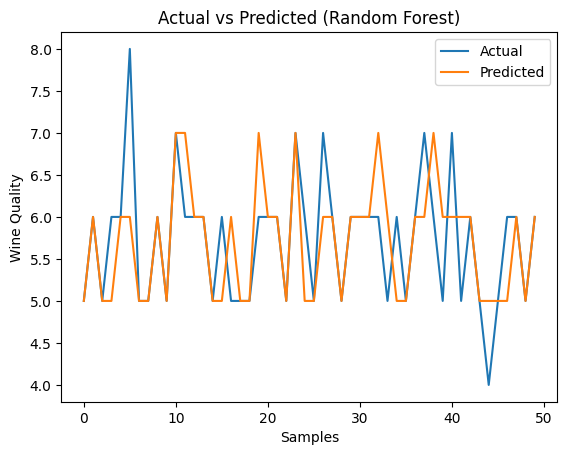

In [ ]:
plt.plot(
    y_test.values[:50],
    label="Actual"
)

plt.plot(
    y_pred_rf[:50],
    label="Predicted"
)

plt.title("Actual vs Predicted (Random Forest)")
plt.xlabel("Samples")
plt.ylabel("Wine Quality")
plt.legend()

plt.show()


In [ ]:
print("\nMODEL ACCURACY SUMMARY")

for model, acc in model_accuracies.items():
    print(model, ":", round(acc*100,2), "%")

best_model = max(
    model_accuracies,
    key=model_accuracies.get
)

print("\nBest Model:", best_model)


MODEL ACCURACY SUMMARY
Logistic Regression : 63.76 %
Decision Tree : 56.33 %
Random Forest : 68.12 %
KNN : 55.9 %

Best Model: Random Forest


In [ ]:
best_wines = df[df['quality'] == df['quality'].max()]
print(best_wines)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
190             7.9              0.35         0.46             3.6      0.078   
197            10.3              0.32         0.45             6.4      0.073   
271             5.6              0.85         0.05             1.4      0.045   
310            12.6              0.31         0.72             2.2      0.072   
321            11.3              0.62         0.67             5.2      0.086   
340             9.4              0.30         0.56             2.8      0.080   
349            10.7              0.35         0.53             2.6      0.070   
352            10.7              0.35         0.53             2.6      0.070   
419             5.0              0.42         0.24             2.0      0.060   
747             9.1              0.40         0.50             1.8      0.071   
769            10.0              0.26         0.54             1.9      0.083   
793             7.9         

<Figure size 1200x700 with 0 Axes>

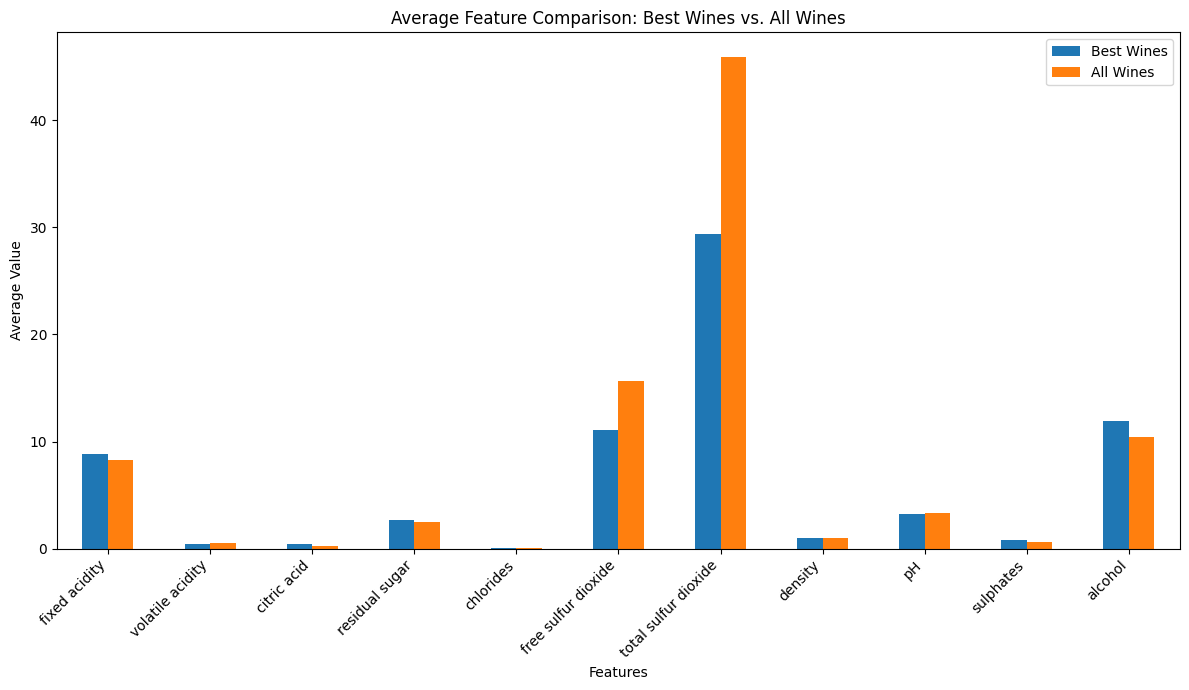

In [ ]:
average_best_wines = best_wines.drop(columns=['Id', 'quality']).mean()
average_all_wines = df.drop(columns=['Id', 'quality']).mean()

comparison_df = pd.DataFrame({'Best Wines': average_best_wines, 'All Wines': average_all_wines})

plt.figure(figsize=(12, 7))
comparison_df.plot(kind='bar', figsize=(12, 7))
plt.title('Average Feature Comparison: Best Wines vs. All Wines')
plt.ylabel('Average Value')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()